<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 7 Day 1: Sprint 2 Planning & Convolution Foundations
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 1 Learning Objectives:</b>
- <b>Sprint 2 Kickoff:</b> Establish the Sprint 2 goal, define the core-model backlog, and carry forward the Sprint 1 retrospective action item.
- <b>Why Dense Networks Fail on Images:</b> Understand the mathematical parameter explosion and loss of 2D spatial locality when flattening images into fully connected layers.
- <b>Convolution Mechanics:</b> Slide small filter kernels across image grids to compute local dot products and generate feature maps.
- <b>Parameter Sharing & Invariance:</b> Analyze how weight sharing and translation invariance enable CNNs to learn visual hierarchies (edges $\rightarrow$ shapes/textures $\rightarrow$ objects) with dramatically fewer weights.
- <b>Architecture Decision Record:</b> Align core model architecture with project data modality.

</blockquote>


---
## <span style="color: #309c42ff">1. Sprint 2 Planning & Core-Model Backlog</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Sprint 2 Goal:</b> Advance and tune the project's core model architecture to decisively outperform the Week 6 baseline benchmark, carrying forward the process improvement identified in the Sprint 1 retrospective.

</blockquote>

### Sprint 2 Core-Model Backlog Tasks:

1. **Task 1 (Architecture Selection & Justification):** Confirm whether the project dataset calls for a CNN, RNN/Transformer, or Dense Neural Network based on data modality.
2. **Task 2 (Specialized Deep Learning Exploration):**
   - Implement convolution, pooling, data augmentation, and transfer learning for vision tasks.
   - Implement recurrent architectures (RNN, LSTM, GRU) and embeddings for sequential data.
   - Implement self-attention and Hugging Face Transformers for NLP tasks.
3. **Task 3 (Mid-Sprint Mentor Review):** Open a GitHub pull request on Day 3 for the Mentor Code & Notebook Review and address feedback.
4. **Task 4 (Model Tuning & Experiment Logging):** Systematically tune hyperparameters and log all configurations and evaluation metrics in MLflow.
5. **Task 5 (Sprint Review & Retrospective):** Assemble training curves, construct baseline comparison metric tables, present the Sprint Review demo, and record one concrete action item for Sprint 3.

### Retrospective Improvement Carried Forward from Sprint 1:
- Enforce strict baseline-first discipline and systematic experiment logging (tracking hyperparameters, loss curves, and validation metrics) before finalizing architectural enhancements.


---
## <span style="color: #309c42ff">2. Hand-Defined Convolution & Feature Map Extraction</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

A convolution slides a small filter (kernel)—a tiny grid of weights (e.g., $3 \times 3$)—across an image, computing a localized dot product at each position. Each filter learns to detect one specific pattern (a vertical edge, a curve, a texture). The output is a <b>feature map</b> showing where in the image that pattern appears.

</blockquote>

### Mathematical Formulation:

$$(\mathbf{I} * \mathbf{K})(i, j) = \sum_{m} \sum_{n} \mathbf{I}(i+m, j+n) \mathbf{K}(m, n)$$

### Convolution Concepts:

| Concept | Meaning & Operational Role |
| :--- | :--- |
| **Filter / Kernel** | A small grid of learnable weights that slides across the input to detect a specific local pattern (vertical edge, curve, texture). |
| **Feature Map** | The 2D output grid showing the activation response and spatial location where the filter's pattern was detected. |
| **Stride** | The step size (number of pixels) the filter shifts horizontally and vertically across each step. |
| **Padding** | Adding border rows and columns (typically zeros) around the input image so the filter can process edge pixels and preserve output spatial dimensions. |

### Directional Edge Filters (Sobel Kernels):

$$\mathbf{K}_{\text{vertical}} = \begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix}, \quad \mathbf{K}_{\text{horizontal}} = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ +1 & +2 & +1 \end{bmatrix}$$

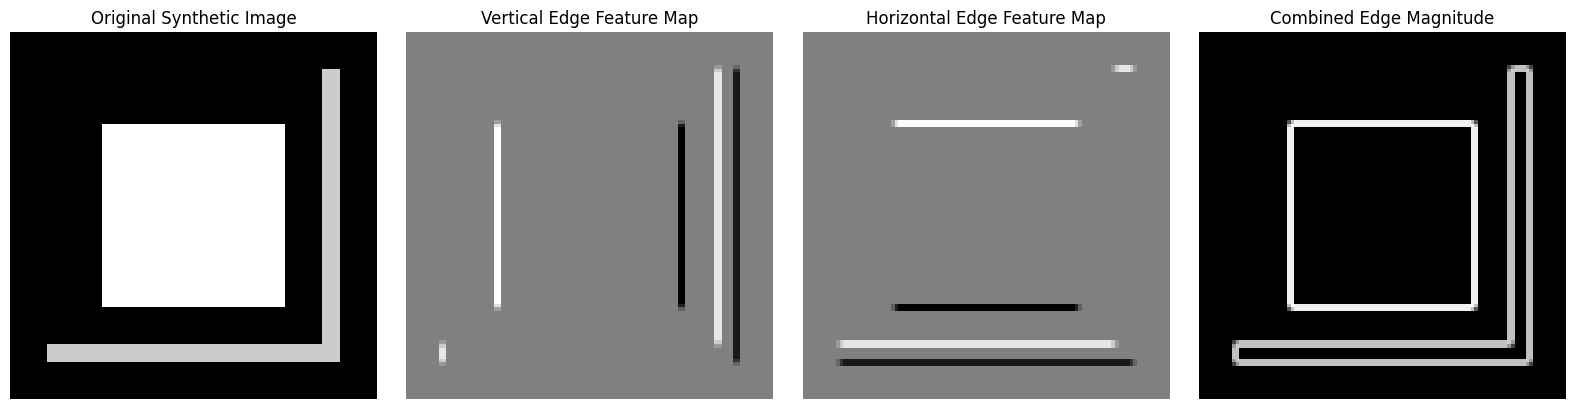

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def create_synthetic_image(size=(100, 100)):
    img = np.zeros(size, dtype=np.float32)
    img[25:75, 25:75] = 1.0
    img[10:90, 85:90] = 0.8
    img[85:90, 10:90] = 0.8
    return img

def convolve2d_manual(image, kernel, stride=1, padding=1):
    k_h, k_w = kernel.shape
    img_h, img_w = image.shape
    
    pad_img = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    
    out_h = (img_h + 2 * padding - k_h) // stride + 1
    out_w = (img_w + 2 * padding - k_w) // stride + 1
    
    feature_map = np.zeros((out_h, out_w), dtype=np.float32)
    
    for i in range(out_h):
        for j in range(out_w):
            r_start = i * stride
            r_end = r_start + k_h
            c_start = j * stride
            c_end = c_start + k_w
            
            receptive_field = pad_img[r_start:r_end, c_start:c_end]
            feature_map[i, j] = np.sum(receptive_field * kernel)
            
    return feature_map

kernel_vertical_edge = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

kernel_horizontal_edge = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

input_image = create_synthetic_image(size=(100, 100))
feature_map_vertical = convolve2d_manual(input_image, kernel_vertical_edge, stride=1, padding=1)
feature_map_horizontal = convolve2d_manual(input_image, kernel_horizontal_edge, stride=1, padding=1)

feature_map_combined = np.sqrt(feature_map_vertical**2 + feature_map_horizontal**2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(input_image, cmap='gray')
axes[0].set_title("Original Synthetic Image")
axes[0].axis('off')

axes[1].imshow(feature_map_vertical, cmap='gray')
axes[1].set_title("Vertical Edge Feature Map")
axes[1].axis('off')

axes[2].imshow(feature_map_horizontal, cmap='gray')
axes[2].set_title("Horizontal Edge Feature Map")
axes[2].axis('off')

axes[3].imshow(feature_map_combined, cmap='gray')
axes[3].set_title("Combined Edge Magnitude")
axes[3].axis('off')

plt.tight_layout()
plt.show()

---
## <span style="color: #309c42ff">3. Analytical Weight Comparison (Dense vs. Conv2D)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

A $200 \times 200$ color image has $200 \times 200 \times 3 = 120,000$ numbers. Feeding it into a dense network means the first layer alone needs millions of weights—it is computationally hopeless and ignores a key fact: in an image, nearby pixels are related, and a pattern is the same wherever it appears. Dense networks throw away this spatial structure entirely.

</blockquote>

### Mathematical Comparison ($200 \times 200 \times 3$ Image with 32 Units / Filters):

| Architecture Layer | Layer Specification | Parameter Calculation Formula | Total Trainable Parameters |
| :--- | :--- | :--- | :--- |
| **Fully Connected (Dense)** | 32 hidden neurons (flattened input) | $(120,000 \times 32) + 32$ | **3,840,032** |
| **Convolutional (Conv2D)** | 32 filters of size $3 \times 3 \times 3$ | $(3 \times 3 \times 3 \times 32) + 32$ | **896** |

**Parameter Reduction:** The Conv2D layer achieves a **~4,285x reduction in parameters** over the dense layer.

### Why Convolution Wins:

1. **Parameter Sharing:** The same small filter is reused across the entire image, so a CNN needs vastly fewer weights than a dense network.

2. **Translation Invariance:** Because the filter slides everywhere, a pattern is detected no matter where it appears.

3. **Local Receptive Fields:** Restricts computation to adjacent pixels where strong spatial correlation exists.

4. **Feature Hierarchy:** Early layers detect simple patterns (edges), middle layers combine them (shapes, textures), and deep layers recognize whole objects (faces, cars).

---

## <span style="color:#9f43c3ff">5. Step 4: Capstone Core Model Architecture Decision Record</span>

### Architecture Mapping Matrix:

| Project Data Type | Core Architecture |
| :--- | :--- |
| **Tabular (churn, house price, fraud)** | **Dense network (Week 6) or gradient boosting; deep learning optional** |
| **Images (image classifier)** | **CNN with transfer learning (Day 2)** |
| **Text (sentiment analysis)** | **LSTM or a pre-trained transformer (Days 3–4)** |
| **Sequences / Time Series** | **LSTM / GRU (Day 3)** |

### Formal Decision Record:

-  **Selected Core Architecture:** **Convolutional Neural Network (CNN) with Transfer Learning**.

-  **Justification:** Image data contains dense spatial dependencies where adjacent pixels define local visual patterns (edges, curves, textures). CNNs leverage parameter sharing and local receptive fields to extract hierarchical visual features while avoiding the parameter explosion of dense networks.

-  **Sprint 2 Target:** Build, evaluate, and tune a CNN with transfer learning (e.g., MobileNetV2 / ResNet) to outperform the baseline model.
